# Agent X Reversibility effect

Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

## Overall Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [21]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

1. Contingency Table

In [22]:
contingency = pd.crosstab(
    [subgroup_theoretical["Agent"], subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"]
)

contingency

Response_Full                   L1_transfer  L2_other  correct
Agent Consequent_Reversibility                                
0     No                                 21         9       12
      Yes                                36        22       23
1     No                                 16         1        7
      Yes                                23         6       19

2. Proportions

In [23]:
proportions = pd.crosstab(
    [subgroup_theoretical["Agent"],subgroup_theoretical["Consequent_Reversibility"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full                   L1_transfer  L2_other   correct
Agent Consequent_Reversibility                                 
0     No                           0.500000  0.214286  0.285714
      Yes                          0.444444  0.271605  0.283951
1     No                           0.666667  0.041667  0.291667
      Yes                          0.479167  0.125000  0.395833

3. Chi-Square Test

In [24]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 9.909
p-value: 0.1285
Degrees of freedom: 6


There is no evidence that response distribution differs across reversibility conditions.

4. Expected Counts

In [25]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full                   L1_transfer   L2_other    correct
Agent Consequent_Reversibility                                   
0     No                          20.676923   8.184615  13.138462
      Yes                         39.876923  15.784615  25.338462
1     No                          11.815385   4.676923   7.507692
      Yes                         23.630769   9.353846  15.015385

In [26]:
print(expected_df < 5)

Response_Full                   L1_transfer  L2_other  correct
Agent Consequent_Reversibility                                
0     No                              False     False    False
      Yes                             False     False    False
1     No                              False      True    False
      Yes                             False     False    False


There is a group with fewer than 5 observations.

5. Cramér's V

In [27]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.159


V = 0.159: 

6. Standardized Residuals

In [28]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full                   L1_transfer  L2_other   correct
Agent Consequent_Reversibility                                 
0     No                           0.071050  0.285012 -0.314084
      Yes                         -0.613941  1.564412 -0.464558
1     No                           1.217395 -1.700217 -0.185288
      Yes                         -0.129757 -1.096599  1.028296

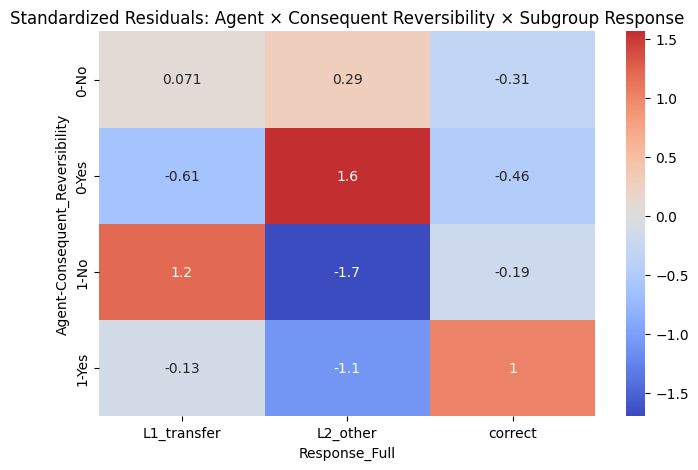

In [29]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Agent × Consequent Reversibility × Subgroup Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association
- Does this support the reversibility hypothesis?
- What remains unexplained?

Although residuals suggest a tendency for irreversible scenarios to elicit more L1-transfer responses than expected and reversible scenarios to elicit fewer, the overall association between Consequent Reversibility and response type is weak and non-significant (χ²(2)=2.11, p=.35, Cramér’s V=.10).

Therefore, Consequent Reversibility on its own cannot account for response distribution in the theoretical subgroup.

This suggests that the effect of reversibility may depend on additional contextual variables like Agency and/or Goal Type.

## Actors Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [30]:
subgroup_actors = subgroup_theoretical[subgroup_theoretical["Focus"] == "I"].copy()

1. Contingency Table

In [31]:
contingency = pd.crosstab(
    [subgroup_actors["Agent"], subgroup_actors["Consequent_Reversibility"]],
    subgroup_actors["Response_Full"]
)

contingency

Response_Full                   L1_transfer  L2_other  correct
Agent Consequent_Reversibility                                
0     No                                  7         8        9
      Yes                                19        11       15
1     No                                 11         1        4
      Yes                                16         4       12

2. Proportions

In [32]:
proportions = pd.crosstab(
    [subgroup_actors["Agent"],subgroup_actors["Consequent_Reversibility"]],
    subgroup_actors["Response_Full"],
    normalize="index"
)

proportions

Response_Full                   L1_transfer  L2_other   correct
Agent Consequent_Reversibility                                 
0     No                           0.291667  0.333333  0.375000
      Yes                          0.422222  0.244444  0.333333
1     No                           0.687500  0.062500  0.250000
      Yes                          0.500000  0.125000  0.375000

3. Chi-Square Test

In [33]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 9.006
p-value: 0.1732
Degrees of freedom: 6


4. Expected Counts

In [34]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full                   L1_transfer  L2_other    correct
Agent Consequent_Reversibility                                  
0     No                          10.871795  4.923077   8.205128
      Yes                         20.384615  9.230769  15.384615
1     No                           7.247863  3.282051   5.470085
      Yes                         14.495726  6.564103  10.940171

In [35]:
print(expected_df < 5)

Response_Full                   L1_transfer  L2_other  correct
Agent Consequent_Reversibility                                
0     No                              False      True    False
      Yes                             False     False    False
1     No                              False      True    False
      Yes                             False     False    False


There are 2 groups with fewer than 5  observations

5. Cramér's V

In [36]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.196


V = 0.196: 

6. Standardized Residuals

In [37]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full                   L1_transfer  L2_other   correct
Agent Consequent_Reversibility                                 
0     No                          -1.174253  1.386750  0.277495
      Yes                         -0.306675  0.582325 -0.098058
1     No                           1.393714 -1.259658 -0.628558
      Yes                          0.395100 -1.000801  0.320423

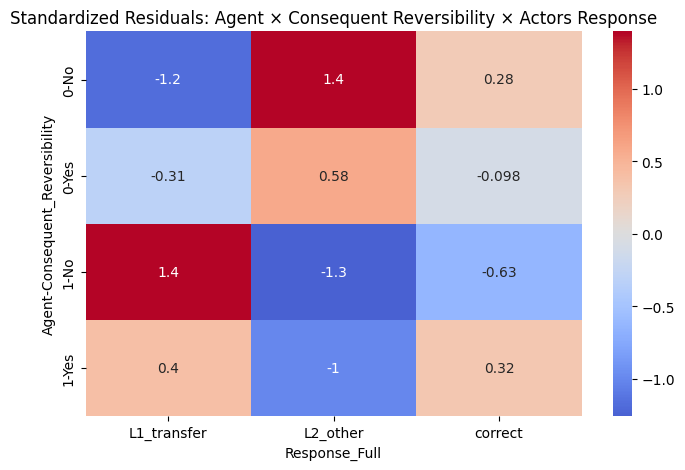

In [38]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Agent × Consequent Reversibility × Actors Response")
plt.show()

7. Interpretation